In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
import warnings

# Settings
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None
%matplotlib inline

# Path to your dataset
DATA_PATH = '/content/EastWestAirlines.csv'

In [9]:
# Load the data
df = pd.read_csv(DATA_PATH)

# Check the first few rows and column names
print("Dataset Shape:", df.shape)
display(df.head())

# Drop the 'ID#' column as it's just an identifier, not a feature
if 'ID#' in df.columns:
    df_clean = df.drop(['ID#'], axis=1)
    print("\n'ID#' column dropped successfully.")
else:
    df_clean = df.copy()

# Check for missing values
print("\nMissing Values:\n", df_clean.isnull().sum())

Dataset Shape: (3999, 12)


,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1



'ID#' column dropped successfully.

Missing Values:
 Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64


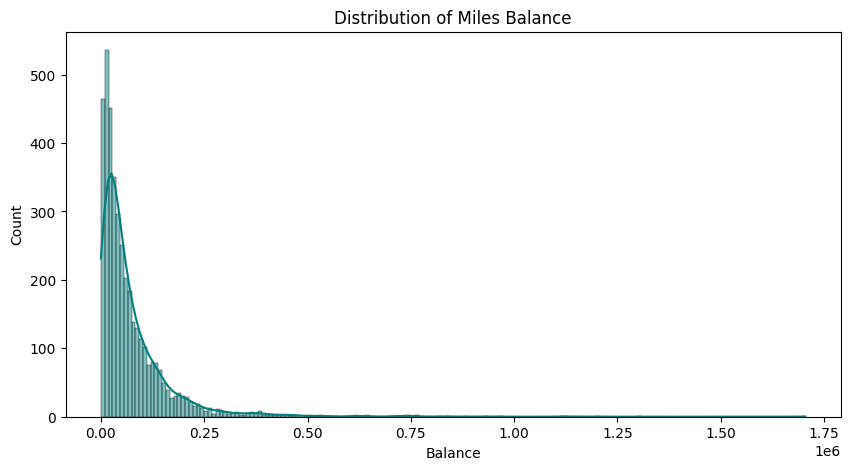

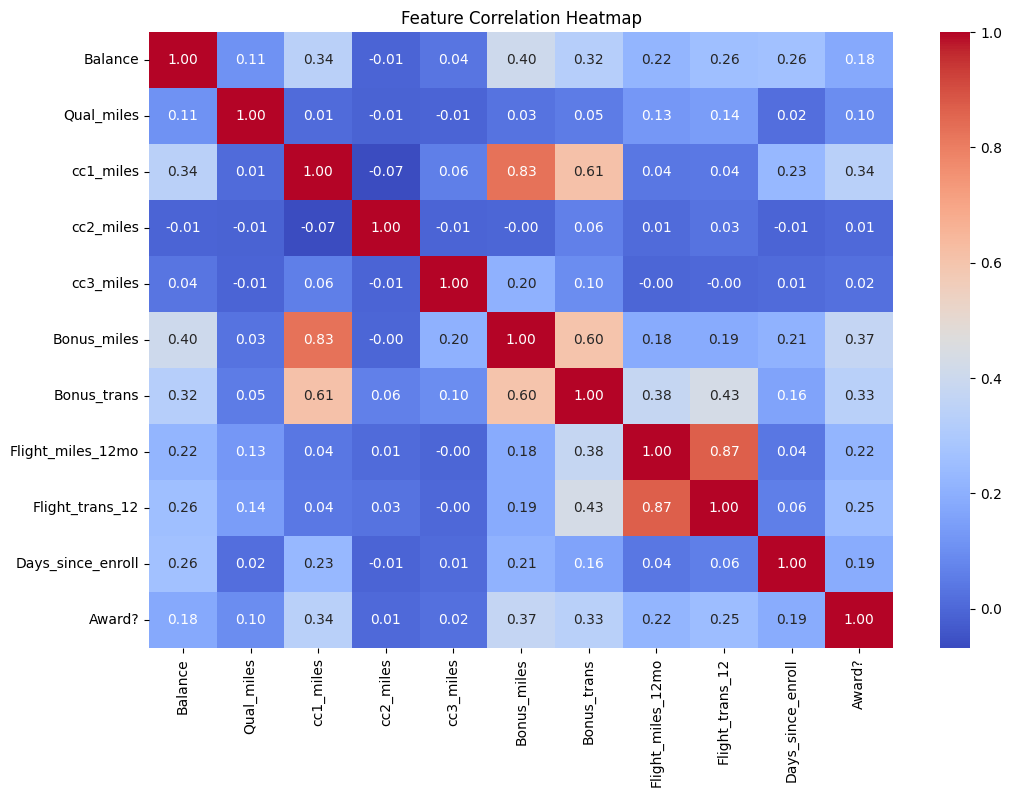

In [10]:
# Distribution of Miles Balance
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['Balance'], kde=True, color='teal')
plt.title('Distribution of Miles Balance')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

In [11]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean)

print("Data has been scaled. Shape of scaled data:", df_scaled.shape)

Data has been scaled. Shape of scaled data: (3999, 11)


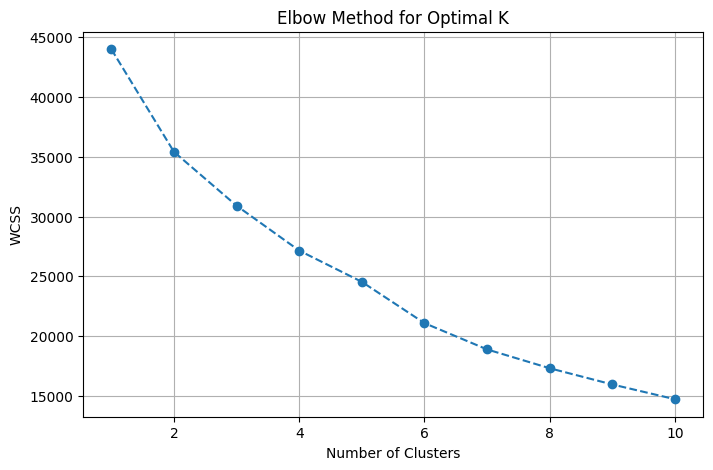

In [12]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

K-Means Silhouette Score: 0.3189


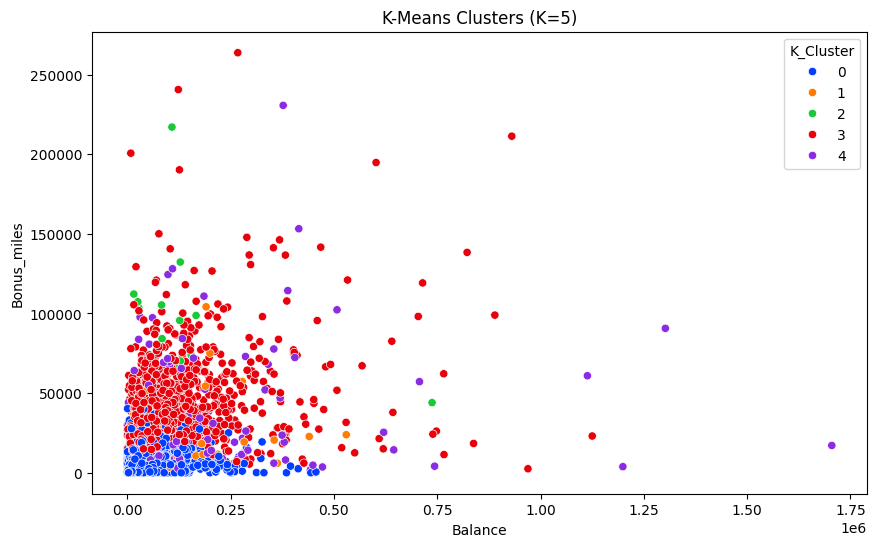

In [13]:
# Apply K-Means
k_clusters = 5
kmeans_model = KMeans(n_clusters=k_clusters, init='k-means++', random_state=42, n_init=10)
df_clean['K_Cluster'] = kmeans_model.fit_predict(df_scaled)

# Calculate Silhouette Score
k_score = silhouette_score(df_scaled, df_clean['K_Cluster'])
print(f"K-Means Silhouette Score: {k_score:.4f}")

# Visualization: Balance vs Bonus Miles
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Balance', y='Bonus_miles', hue='K_Cluster', data=df_clean, palette='bright')
plt.title(f'K-Means Clusters (K={k_clusters})')
plt.show()

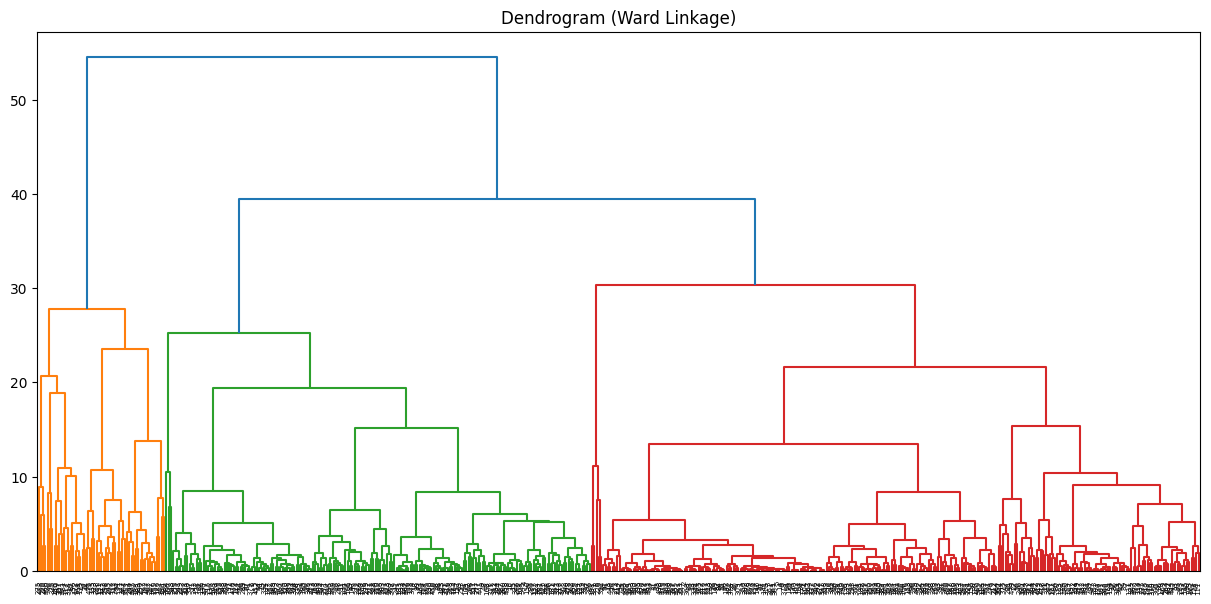

Hierarchical Clustering Silhouette Score: 0.3099


In [14]:
# Plot Dendrogram (using 'ward' linkage)
plt.figure(figsize=(15, 7))
plt.title("Dendrogram (Ward Linkage)")
# Taking a slice of 500 rows for better visibility in the plot
dendrogram = sch.dendrogram(sch.linkage(df_scaled[:500], method='ward'))
plt.show()

# Apply Agglomerative Clustering
h_clusters = 5
hc = AgglomerativeClustering(n_clusters=h_clusters, linkage='ward')
df_clean['H_Cluster'] = hc.fit_predict(df_scaled)

h_score = silhouette_score(df_scaled, df_clean['H_Cluster'])
print(f"Hierarchical Clustering Silhouette Score: {h_score:.4f}")

Number of clusters found by DBSCAN: 6
Number of noise points: 310


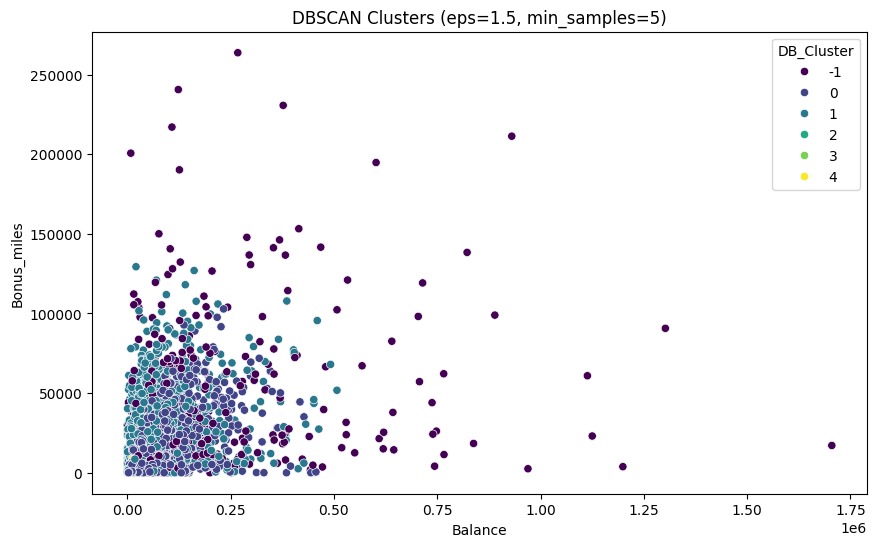

In [15]:
# Tuning DBSCAN (Example parameters)
eps = 1.5
min_samples = 5

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
df_clean['DB_Cluster'] = dbscan.fit_predict(df_scaled)

# Identify noise (-1) vs clusters
n_clusters_db = len(set(df_clean['DB_Cluster'])) - (1 if -1 in df_clean['DB_Cluster'] else 0)
print(f"Number of clusters found by DBSCAN: {n_clusters_db}")
print(f"Number of noise points: {list(df_clean['DB_Cluster']).count(-1)}")

# Visualize DBSCAN
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Balance', y='Bonus_miles', hue='DB_Cluster', data=df_clean, palette='viridis')
plt.title(f'DBSCAN Clusters (eps={eps}, min_samples={min_samples})')
plt.show()

In [16]:
print("--- K-Means Cluster Profiles (Means) ---")
display(df_clean.groupby('K_Cluster').mean())

print("\n--- Hierarchical Cluster Profiles (Means) ---")
display(df_clean.groupby('H_Cluster').mean())

# Compare counts
print("\nPoints per K-Means Cluster:")
print(df_clean['K_Cluster'].value_counts())

--- K-Means Cluster Profiles (Means) ---


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,H_Cluster,DB_Cluster
K_Cluster,,,,,,,,,,,,,
0,43837.679305,43.855450,1.226698,1.019352,1.000395,4753.095972,6.969194,200.140600,0.624408,3711.462875,0.203002,0.981043,0.218799
1,119660.491803,5351.065574,2.000000,1.000000,1.000000,18683.475410,12.229508,963.639344,2.868852,3971.491803,0.557377,0.032787,-0.803279
2,138061.400000,78.800000,3.466667,1.000000,4.066667,93927.866667,28.066667,506.666667,1.600000,4613.866667,0.533333,4.000000,-1.000000
3,117361.299839,56.463826,3.721061,1.002412,1.001608,39502.667203,18.836817,346.309486,1.032154,4882.864148,0.648714,0.084405,0.507235
4,190251.952381,458.734694,2.224490,1.040816,1.000000,32907.979592,28.231293,5685.823129,16.523810,4673.081633,0.802721,1.741497,-0.727891



--- Hierarchical Cluster Profiles (Means) ---


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,K_Cluster,DB_Cluster
H_Cluster,,,,,,,,,,,,,
0,116134.226872,367.779736,3.500000,1.000000,1.000000,36501.331865,17.958884,376.402349,1.147577,4699.638767,0.665198,2.640969,0.472100
1,46329.336877,9.028618,1.244072,1.000000,1.000000,4868.112428,6.907604,214.812756,0.673753,3769.337694,0.184383,0.107931,0.177433
2,134880.892308,393.323077,2.430769,1.000000,1.000000,36582.169231,29.338462,5915.523077,16.638462,4599.607692,0.753846,3.761538,-0.800000
3,68876.581395,23.255814,1.139535,2.348837,1.000000,14689.837209,17.534884,582.627907,2.209302,3968.930233,0.395349,0.581395,1.372093
4,129951.388889,65.666667,3.388889,1.000000,3.722222,86259.888889,26.222222,422.222222,1.333333,4488.777778,0.500000,2.000000,-1.000000



Points per K-Means Cluster:
K_Cluster
0    2532
3    1244
4     147
1      61
2      15
Name: count, dtype: int64
